# E-Commerce Data Analysis Report

This Jupyter Notebook connects to an e-commerce MySQL database and performs various data analysis tasks using Python. The main objectives of this notebook are to:

- Explore customer demographics and locations
- Analyze product categories and pricing
- Understand order behavior and review patterns
- Visualize key insights using graphs

The tools used in this analysis include:
- `MySQL` for querying data
- `pandas` and `numpy` for data manipulation
- `matplotlib` and `seaborn` for visualizations

In [2]:
import os
from dotenv import load_dotenv
import mysql.connector as mysql
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()

DB_HOST = os.getenv("DB_HOST", "localhost")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_NAME = os.getenv("DB_NAME", "ecommerce")

mydb = mysql.connect(
    host=DB_HOST,
    user=DB_USER,
    password=DB_PASSWORD,
    database=DB_NAME,
    auth_plugin='caching_sha2_password'
)

mycursor = mydb.cursor()

This code sets up a connection to a MySQL database and imports essential Python libraries for data analysis and visualization.

**Database Connection:**
- Connects to a local MySQL server using root credentials
- Accesses an "ecommerce" database
- Uses caching_sha2_password authentication

**Imported Libraries:**
- **mysql.connector**: MySQL database connectivity
- **pandas**: Data manipulation and analysis
- **numpy**: Numerical computing
- **matplotlib.pyplot**: Basic plotting and visualization
- **seaborn**: Statistical data visualization

The setup creates a database cursor object (`mycursor`) ready for executing SQL queries on the ecommerce database.

## Unique cities where customers are located

In [3]:
query="""SELECT DISTINCT
    (customer_city)
FROM
    customers"""
city = pd.read_sql(query, mydb)
print(city)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\1828294744.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  city = pd.read_sql(query, mydb)


              customer_city
0                    franca
1     sao bernardo do campo
2                 sao paulo
3           mogi das cruzes
4                  campinas
...                     ...
4114                 siriji
4115    natividade da serra
4116           monte bonito
4117             sao rafael
4118      eugenio de castro

[4119 rows x 1 columns]


The analysis of the customer data reveals 4119 distinct cities where customers are located. These cities represent the geographical spread of the customer base.

Strategic Business Use Cases and Values:

| Use Case Category                  | Strategic Business Use Case                                                                                                    | Value Proposition                                                                                                                                                                                                                            |
| :--------------------------------- | :----------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Targeted Marketing and Advertising** | Develop and execute geo-targeted marketing campaigns. For instance, specific promotions or advertisements can be tailored to the unique demographics or preferences observed within each of the 4119 distinct cities. |  Increased campaign effectiveness, higher conversion rates, and optimized marketing spend by focusing resources on relevant geographical areas.                                                                         |
| **Logistics and Supply Chain Optimization** | Optimize delivery routes, warehouse placements, and inventory management by understanding the concentration of customers in these diverse cities. This can involve establishing new distribution centers or refining existing logistics networks. | Reduced shipping costs, faster delivery times, improved customer satisfaction, and enhanced operational efficiency.                                                                               |
| **Market Expansion and Business Development** | Identify untapped or underserved markets by analyzing the distribution of customers across these cities. Businesses can strategically plan expansion into cities with high potential but currently low customer penetration. | Informed decision-making for market entry, identification of new growth opportunities, and effective resource allocation for business development initiatives.                                                                                   |
| **Sales Territory Planning** | Design sales territories based on customer density and geographical spread across the 4119 cities. This enables sales teams to focus their efforts effectively and efficiently. | Optimized sales force deployment, improved sales performance, and better coverage of the customer base.                                                                           |
| **Risk Management and Business Continuity** | Assess geographical risks (e.g., natural disasters, local economic downturns) by understanding the distribution of the customer base. Develop contingency plans for regions with high concentrations of customers.                 | Enhanced business resilience, minimized disruption to operations, and proactive mitigation of potential risks.                                                           |

By leveraging this detailed geographical insight into the customer base, businesses can make data-driven decisions that lead to significant improvements in operational efficiency, market penetration, and customer satisfaction.

## No. of orders placed in each year

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\2955277703.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  yearly_orders = pd.read_sql(query, mydb)


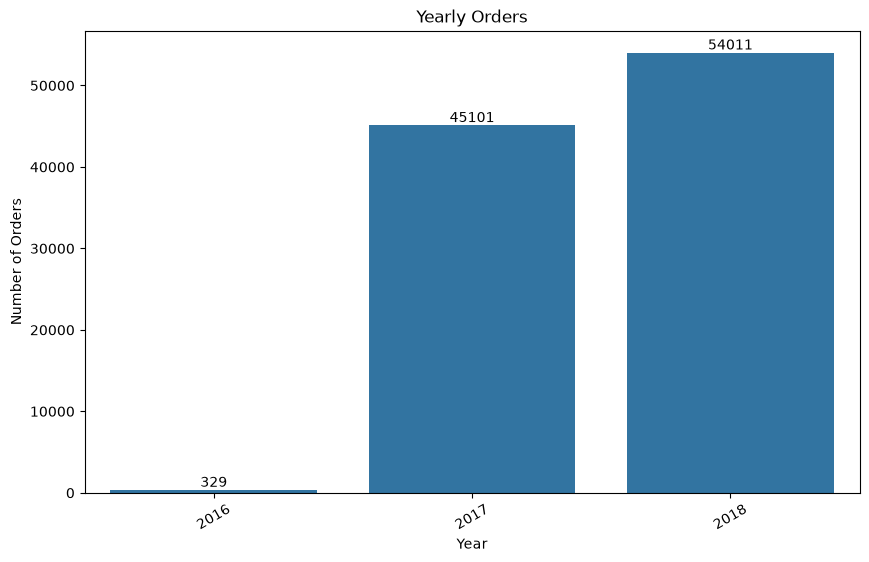

In [4]:
query="""SELECT 
    YEAR(order_purchase_timestamp) AS Year,
    COUNT(order_id) AS Order_Count
FROM
    orders
WHERE
    YEAR(order_purchase_timestamp) IN (2016, 2017, 2018)
GROUP BY YEAR(order_purchase_timestamp)
ORDER BY Year"""

yearly_orders = pd.read_sql(query, mydb)
orders = [2016, 2017, 2018]
plt.figure(figsize=(10, 6))
bars = sns.barplot(x='Year', y='Order_Count', data=yearly_orders, order=orders)
plt.bar_label(bars.containers[0])
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.title('Yearly Orders')
plt.xticks(rotation=30)
plt.show()

The analysis of customer orders from 2016 to 2018 reveals a significant growth trend in the number of orders placed each year:

  - In 2016, a total of 329 orders were recorded.
  - In 2017, the number of orders increased to 45101.
  - By 2018, the order count surged to 54011, indicating a robust expansion in customer transactions.

This consistent year-over-year growth underscores a positive market reception and increasing customer engagement.

Strategic Business Use Cases:

| Use Case Category                  | Strategic Business Use Case                                                                                                    | Value Proposition                                                                                                                                                                                                                            |
| :--------------------------------- | :----------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Sales and Revenue Forecasting** | Utilize the historical growth trend in orders to project future sales and revenue. This data can inform financial planning and budget allocation. |  Utilize the historical growth trend in orders to project future sales and revenue. This data can inform financial planning and budget allocation.                                                                         |
| **Marketing and Acquisition Strategy** | Analyze the growth pattern to understand the effectiveness of past marketing and customer acquisition efforts. The consistent increase suggests successful strategies that can be scaled or replicated. | Informed optimization of marketing campaigns, identification of high-impact channels, and efficient customer acquisition.                                                                               |
| **Operational Planning and Scalability** | Plan for increased operational capacity in areas such as fulfillment, logistics, and customer support, based on the rising order volume. This includes staffing, infrastructure, and inventory management. | Proactive prevention of bottlenecks, maintaining service quality during peak demand, and ensuring seamless scalability of business operations.                                                                                   |
| **Product and Service Development** | The sustained growth indicates a healthy market for existing offerings. This trend can justify further investment in product development, diversification, or enhancement of current services to meet growing demand. | Data-driven decisions for R\&D, ensuring that product roadmaps align with market growth, and maximizing return on investment in new offerings.                                                                           |
| **Investor Relations and Business Valuation** | Present the year-over-year order growth as a key performance indicator (KPI) to potential investors or stakeholders, demonstrating the company's strong market traction and growth potential.                 | Increased investor confidence, enhanced business valuation, and improved attractiveness for funding or partnerships.                                                           |

## Total sales per category

In [5]:
query = """SELECT 
    UPPER(product_category) AS Product_Category, ROUND(SUM(payment_value), 2) AS Total_Sales
FROM
    products
        JOIN
    order_items ON products.product_id = order_items.product_id
        JOIN
    payments ON payments.order_id = order_items.order_id
GROUP BY product_category"""

sales = pd.read_sql(query, mydb)
print(sales)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\2894283186.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sales = pd.read_sql(query, mydb)


               Product_Category  Total_Sales
0                     PERFUMERY    506738.66
1          FURNITURE DECORATION   1430176.39
2                     TELEPHONY    486882.05
3                BED TABLE BATH   1712553.67
4                    AUTOMOTIVE    852294.33
..                          ...          ...
69               CDS MUSIC DVDS      1199.43
70                   LA CUISINE      2913.53
71  FASHION CHILDREN'S CLOTHING       785.67
72                     PC GAMER      2174.43
73       INSURANCE AND SERVICES       324.51

[74 rows x 2 columns]


The analysis of sales data by product category reveals the following key insights:

  - The dataset contains sales information across 73 distinct product categories.
  - The top-performing category is **BED TABLE BATH** with total sales of $1712553.67.
  - The categories with the lowest sales include **INSURANCE AND SERVICES** with $324.51, indicating areas that may require strategic review or discontinuation.

This distribution highlights varying levels of market demand and customer engagement across different product segments.

Strategic Business Use Cases and Values:

| Use Case Category                  | Strategic Business Use Case                                                                                                    | Value Proposition                                                                                                                                                                                                                            |
| :--------------------------------- | :----------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Product Portfolio Optimization** | Identify high-performing and underperforming product categories. This information can guide decisions on product development, marketing focus, and inventory management. High-performing categories can be prioritized for investment, while underperforming ones might need re-evaluation or phasing out. |  Maximized profitability by allocating resources effectively, reduced inventory holding costs for slow-moving items, and enhanced overall product portfolio health.                                                                         |
| **Marketing and Promotional Strategy** | Tailor marketing campaigns to specific categories. For top categories, focus on customer retention and upselling. For lower-performing categories, implement targeted promotional activities or redesign marketing messages to boost sales. | Increased return on marketing investment (ROI), improved customer acquisition and retention, and better brand positioning within each product segment.                                                                               |
| **Sales Performance Analysis and Goal Setting** | Set realistic sales targets for each category based on historical performance. Sales teams can be incentivized to focus on high-potential categories or improve sales in underperforming ones. | Enhanced sales team motivation and efficiency, clearer performance metrics, and more achievable business goals.                                                                                   |
| **Supply Chain and Inventory Management** | Optimize procurement and inventory levels for each product category based on their sales volume. Ensure sufficient stock for popular categories while minimizing overstocking for less popular ones. | Reduced carrying costs, improved cash flow, minimized stockouts for high-demand products, and streamlined supply chain operations.                                                                           |
| **Pricing Strategy and Competitive Analysis** | Analyze sales performance in conjunction with pricing strategies. For high-demand categories, explore premium pricing opportunities. For struggling categories, competitive pricing adjustments or value-added propositions might be necessary.                 | Optimized pricing for maximum revenue, increased market share, and effective response to competitive pressures.                                                           |

## Percentage of orders that were paid in installments

In [6]:
query="""SELECT 
    (SUM((CASE
        WHEN payment_installments > 1 THEN 1
        ELSE 0
    END)) / COUNT(*)) * 100 AS Percentage_Installments
FROM
    payments"""


data = pd.read_sql(query, mydb)
print("Percentage of orders with installments:", data['Percentage_Installments'].iloc[0])

Percentage of orders with installments: 49.4176


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\657675354.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql(query, mydb)


The analysis of payment data indicates that **49.4%** of all orders involved payments with one or more installments. This highlights the significant preference or necessity among customers for flexible payment options.

Strategic Business Use Cases and Values:

| Use Case Category                  | Strategic Business Use Case                                                                                                    | Value Proposition                                                                                                                                                                                                                            |
| :--------------------------------- | :----------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Payment Option Strategy** | Reinforce or expand installment payment options, especially if the percentage is high. This data validates the importance of offering flexible payment methods to customers. |  Increased sales conversions, improved accessibility for larger purchases, and enhanced customer satisfaction by meeting diverse financial needs.                                                                         |
| **Marketing and Sales Messaging** | Highlight installment payment availability in marketing campaigns and sales pitches. This can be a strong selling point, particularly for higher-priced items. | Attracting a broader customer base, driving higher average order values, and differentiating from competitors who may not offer similar flexibility.                                                                               |
| **Financial Planning and Cash Flow Management** | Anticipate cash flow patterns based on the prevalence of installment payments. Businesses can better manage their receivables and liquidity. | Improved financial forecasting, optimized working capital, and reduced financial risk.                                                                                   |
| **Risk Assessment and Fraud Prevention** | Monitor installment payment trends for potential fraud indicators, although generally, installment options are not inherently risky. This can involve analyzing payment behavior for unusual patterns. | Enhanced security measures, minimized financial losses due to fraud, and maintaining trust with legitimate customers.                                                                           |
| **Product Pricing and Bundling** | Analyze whether product or service offerings need to be customized to meet specific regional demands or preferences, especially in states with unique characteristics or cultural nuances.                 | Increased sales volume for premium products, improved perceived value of offerings, and stronger competitive positioning.                                                           |

## No. of customers from each state

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\4058098879.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  state_counts = pd.read_sql(query, mydb)


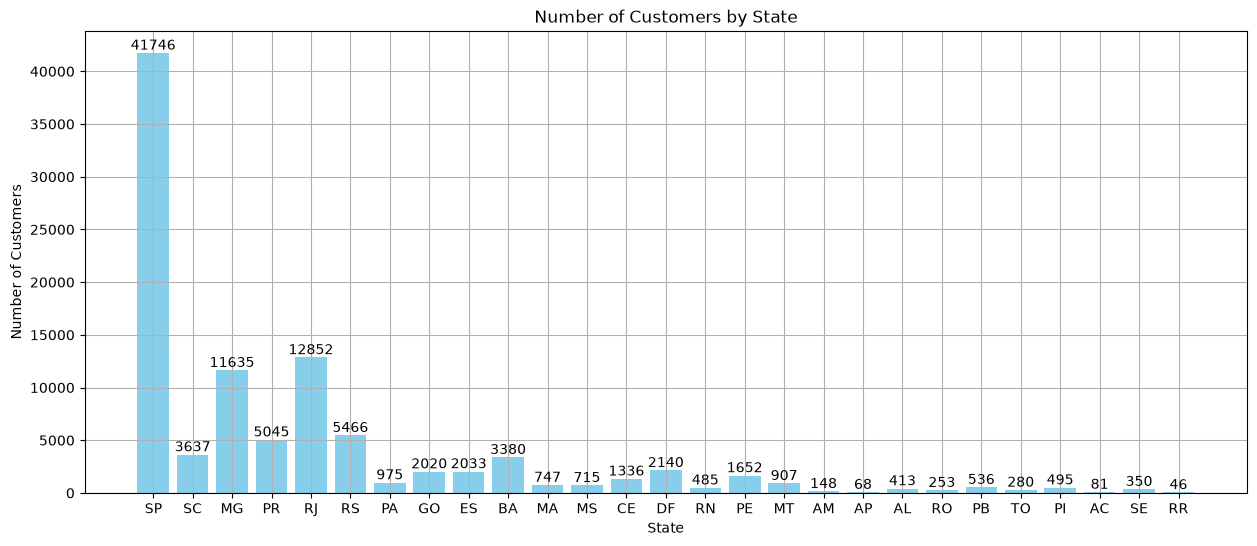

In [7]:
query="""SELECT 
    customer_state AS State, COUNT(*) AS Count
FROM
    customers
GROUP BY customer_state"""

state_counts = pd.read_sql(query, mydb)
plt.figure(figsize=(15, 6))
bars=plt.bar(state_counts['State'], state_counts['Count'], color='skyblue')
plt.bar_label(bars)
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.title('Number of Customers by State')
plt.grid()
plt.show()

The analysis of customer distribution across different states reveals a significant variation in customer density.

  - The state with the highest number of customers is **SP** with **41746** customers.
  - Following closely are states like **RJ** with **12852** customers, and **MG** with **11635** customers.
  - Conversely, states such as **RR** have a very low customer count of **46**, indicating either nascent market presence or limited engagement.

This geographic distribution is crucial for understanding regional market strengths and opportunities.

Strategic Business Use Cases and Values:

| Use Case Category                  | Strategic Business Use Case                                                                                                    | Value Proposition                                                                                                                                                                                                                            |
| :--------------------------------- | :----------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Targeted Marketing and Sales Campaigns** | Allocate marketing and sales resources more effectively by focusing on states with high customer concentrations. Tailor campaigns to resonate with specific regional demographics and preferences. |  Increased ROI on marketing spend, higher conversion rates, and stronger customer engagement in key markets.                                                                         |
| **Logistics and Distribution Network Optimization** | Optimize the placement of warehouses, distribution centers, and delivery routes based on customer density per state. This can reduce shipping costs and improve delivery times. | Enhanced operational efficiency, reduced logistical expenses, and improved customer satisfaction through faster and more reliable deliveries.                                                                               |
| **Market Expansion and Penetration Strategies** | Identify underserved states or regions with low customer counts but high potential for growth. Develop strategies for market entry and aggressive penetration in these areas. | Unlocking new revenue streams, expanding market share, and achieving sustainable long-term growth.                                                                                   |
| **Customer Service and Support Localization** | Establish localized customer support hubs or tailor support services (e.g., language-specific support) for states with a significant customer base. | Improved customer experience, higher customer retention rates, and more efficient resolution of regional customer issues.                                                                           |
| **Product and Service Customization** | Analyze whether product or service offerings need to be customized to meet specific regional demands or preferences, especially in states with unique characteristics or cultural nuances.                 | Increased product relevance, higher adoption rates, and a stronger competitive edge by catering to local market needs.                                                           |

## No. of orders from each product category

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\3781982167.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  product_counts = pd.read_sql(query, mydb)


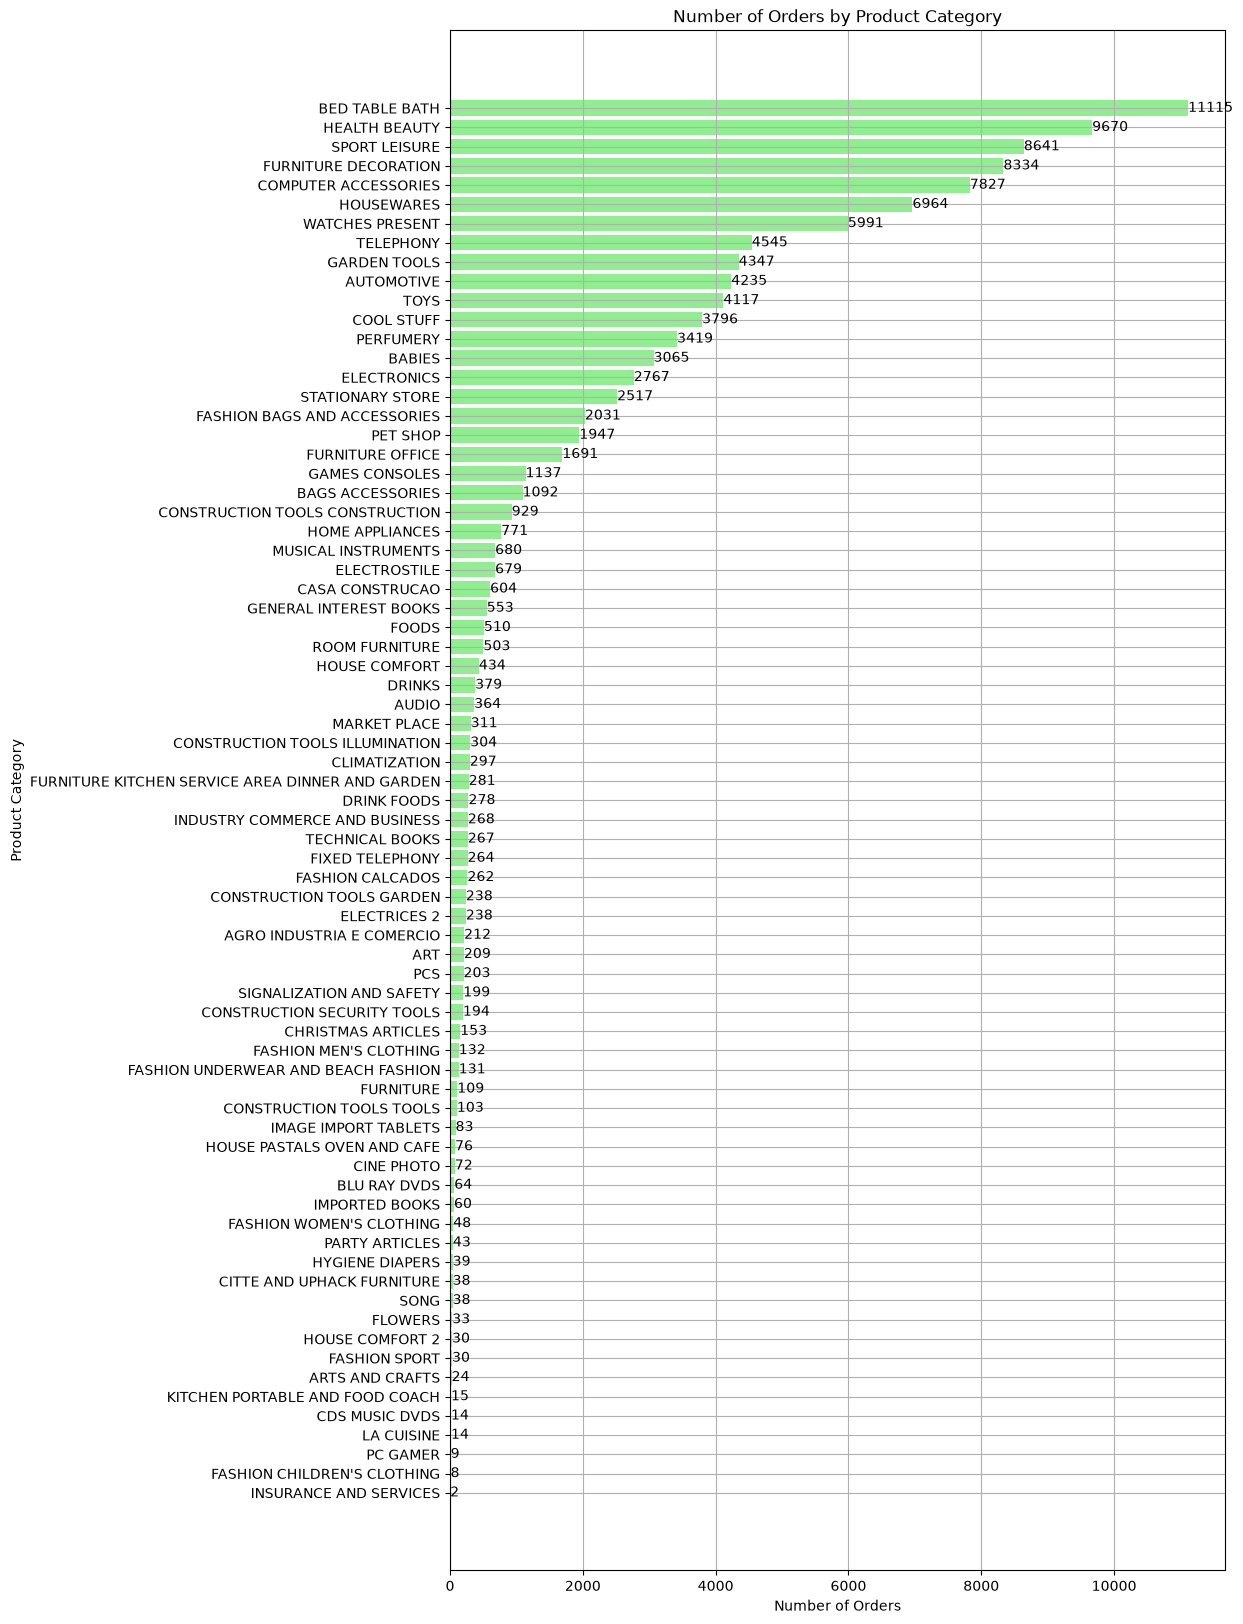

In [8]:
query="""SELECT 
    UPPER(product_category) AS Category, COUNT(*) AS Count
FROM
    products
        JOIN
    order_items ON products.product_id = order_items.product_id
WHERE product_category IS NOT NULL
GROUP BY product_category
ORDER BY COUNT(*) ASC"""

product_counts = pd.read_sql(query, mydb)
plt.figure(figsize=(10, 20))
bars=plt.barh(product_counts['Category'], product_counts['Count'], color='lightgreen')
plt.bar_label(bars)
plt.xlabel('Number of Orders')
plt.ylabel('Product Category')
plt.title('Number of Orders by Product Category')
plt.grid()
plt.show()

The analysis of orders by product category reveals the following distribution:

  - There are 73 distinct product categories.
  - The categories with the highest number of orders are **BED TABLE BATH** with **11115** orders, followed by **HEALTH BEAUTY** with **9670** orders.
  - Conversely, categories like **INSURANCE AND SERVICES** with only **2** orders, and **FASHION CHILDREN'S CLOTHING** with **8** orders, indicate very low order volumes.

This insight into order frequency by category can inform inventory, marketing, and product development strategies.

Strategic Business Use Cases and Values:

| Use Case Category                  | Strategic Business Use Case                                                                                                    | Value Proposition                                                                                                                                                                                                                            |
| :--------------------------------- | :----------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Inventory Management and Stock Optimization** | Use order counts to forecast demand for each product category. Prioritize stocking for high-demand categories to avoid stockouts and reduce inventory for low-demand categories to minimize carrying costs. |  Improved inventory turnover, reduced capital tied up in slow-moving stock, and enhanced supply chain efficiency.                                                                         |
| **Marketing and Promotional Focus** | Develop targeted marketing campaigns based on category popularity. For high-order categories, focus on customer retention and loyalty programs. For low-order categories, devise promotional strategies to boost visibility and sales. | Increased marketing ROI, effective customer acquisition and retention, and optimized promotional spend.                                                                               |
| **Product Development and Diversification** | Invest in expanding product lines within high-order categories. For categories with very low order counts, evaluate whether to discontinue them, redesign them, or explore new product offerings that align with market trends. | Data-driven product portfolio expansion, maximized innovation efforts, and reduced risk of investing in unpopular products.                                                                                   |
| **Sales Strategy and Channel Optimization** | Tailor sales strategies per category. For top categories, consider expanding sales channels. For less popular categories, explore niche markets or specialized sales approaches. | Enhanced sales effectiveness, optimized channel distribution, and improved market penetration.                                                                           |
| **Customer Insights and Personalization** | Understand which product categories resonate most with different customer segments. This allows for personalized product recommendations and cross-selling opportunities.                 | Deeper customer understanding, increased customer lifetime value, and improved conversion rates through tailored offers.                                                           |

## No. of orders per month in 2018

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\530823716.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_orders = pd.read_sql(query, mydb)


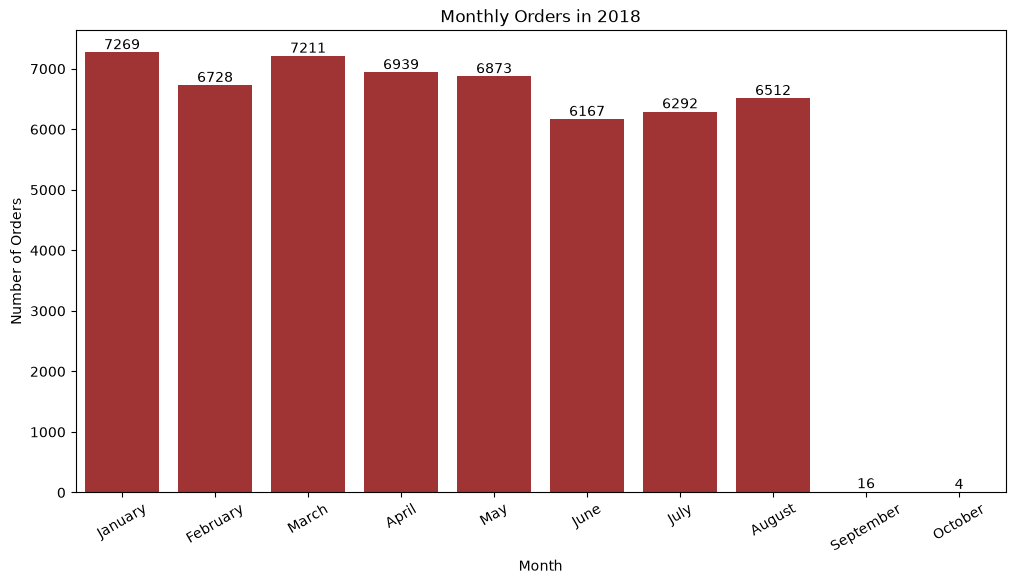

In [10]:
query="""SELECT 
    MONTHNAME(order_purchase_timestamp) AS Month, COUNT(*) AS Order_Count
FROM
    orders
WHERE
    YEAR(order_purchase_timestamp) = 2018
GROUP BY MONTHNAME(order_purchase_timestamp)"""

monthly_orders = pd.read_sql(query, mydb)
plt.figure(figsize=(12, 6))
orders= ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October"]
bars=sns.barplot(x='Month', y='Order_Count', data=monthly_orders, order=orders, color='firebrick')
plt.bar_label(bars.containers[0])
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.title('Monthly Orders in 2018')
plt.xticks(rotation=30)
plt.show()

Our analysis of the 2018 order data reveals a tale of two distinct periods. From **January to August**, the business demonstrated consistent performance, with monthly orders averaging between approximately 6,100 and 7,300. This stability suggests a predictable and steady stream of revenue during the first eight months of the year.

However, there is a **dramatic and alarming drop in orders in September and October**, with only 16 and 4 orders respectively. This sharp decline strongly indicates a potential issue with data collection, a disruption in business operations, or a technical problem with the sales platform during this period. The data for the last quarter of 2018 should be considered incomplete and requires immediate investigation.

Analyzing monthly order trends provides significant strategic value.

Strategic Business Use Cases and Values:

| Use Case Category                  | Strategic Business Use Case                                                                                                    | Value Proposition                                                                                                                                                                                                                            |
| :--------------------------------- | :----------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Demand Forecasting and Inventory Management** | By understanding the consistent order volumes from January to August, you can more accurately forecast demand for the same period in subsequent years. |  This enables optimized inventory management, reducing the costs associated with overstocking and minimizing the risk of lost sales due to stockouts.                                                                         |
| **Marketing and Sales Campaign Planning** | Identifying peak and off-peak months allows for the strategic planning of marketing campaigns. For example, a "summer sale" could be planned for June, which showed a slight dip in orders, to boost sales. | Targeted promotions during slower months can help to smooth out revenue streams, while campaigns during peak months can maximize sales and customer acquisition.                                                                               |
| **Financial Planning and Budgeting** | The predictable revenue pattern observed in the first eight months provides a solid baseline for financial planning and budgeting. | This allows for more accurate revenue projections, better cash flow management, and more confident resource allocation for investments, hiring, and operational expenses.                                                                                   |
| **Operational and Staffing Adjustments** | Knowing the busiest and slowest months allows for flexible staffing in key departments like customer service, warehousing, and logistics. | Efficiently managing staffing levels to match demand improves customer satisfaction by ensuring adequate support during peak times and reduces labor costs during slower periods.                                                                           |
| **Data Integrity and System Health Monitoring** | The drastic drop in orders in September and October serves as a critical alert. This is a clear indicator of a potential problem in the data pipeline, e-commerce platform, or order processing system.                 | Regularly monitoring sales data is not just for business performance, but it's a crucial tool for real-time health checks of your operational and technical systems. Early detection of such anomalies can prevent significant revenue loss and customer dissatisfaction.                                                           |

**Investigating the cause of this data drop is a high-priority action item.**

## Average no. of products per order grouped by customer city

In [13]:
query="""WITH count_order AS (SELECT 
    orders.order_id, customer_id, COUNT(order_items.order_id) AS county
FROM
    orders
        JOIN
    order_items ON orders.order_id = order_items.order_id
GROUP BY orders.order_id , customer_id)

SELECT 
    customer_city AS City, ROUND(AVG(county),2) AS Avg_Products_Per_Order
FROM
    customers
        JOIN
    count_order ON customers.customer_id = count_order.customer_id
GROUP BY customer_city
ORDER BY AVG(county) DESC"""

avg_products_per_order = pd.read_sql(query, mydb)
print(avg_products_per_order)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\1816078519.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  avg_products_per_order = pd.read_sql(query, mydb)


                      City  Avg_Products_Per_Order
0           padre carvalho                     7.0
1              celso ramos                     6.5
2                    datas                     6.0
3            candido godoi                     6.0
4           matias olimpio                     5.0
...                    ...                     ...
4105        lagoa da canoa                     1.0
4106            japaratuba                     1.0
4107        sebastiao leal                     1.0
4108  morro agudo de goias                     1.0
4109         padre paraiso                     1.0

[4110 rows x 2 columns]


The analysis reveals the average number of products per order across various cities, highlighting significant variations in customer purchasing behavior. Cities such as Padre Carvalho (7.00), Celso Ramos (6.50), and Cândido Godói (6.00) show the highest average products per order, indicating a strong propensity for larger basket sizes in these regions. This insight is crucial for understanding geographical purchasing patterns and optimizing business strategies.

Strategic Business Use Cases and Values:

| Business Use Case                                | Strategic Value                                                                                                                                                                                                                                      |
| :----------------------------------------------- | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Targeted Marketing Campaigns** | Identify cities with high average products per order for focused marketing campaigns to encourage even larger purchases, or cities with low averages to promote bundled offers and increase basket size.                                                     |
| **Inventory Management and Logistics** | Optimize inventory levels and distribution center locations based on demand patterns in different cities. Cities with higher average orders might require larger stock of diverse products, leading to more efficient logistics and reduced shipping costs. |
| **Product Bundling and Cross-Selling Strategies** | Develop tailored product bundles or cross-selling recommendations for specific cities. For example, in cities with high average products per order, introduce premium bundles; in others, promote complementary products to increase the average order value. |
| **Sales Performance Evaluation** | Evaluate sales team performance by comparing average products per order across cities. This can help identify successful sales strategies and areas needing improvement, enabling more effective sales training and resource allocation.                    |
| **Customer Segmentation and Loyalty Programs** | Segment customers by city based on their purchasing behavior. This data can inform the creation of city-specific loyalty programs or incentives that reward customers for higher average orders, fostering stronger customer relationships and retention.     |

This data-driven approach allows for a more strategic allocation of resources, improved operational efficiency, and a more personalized customer experience, ultimately contributing to sustainable business growth.

## Percentage of total revenue contributed by each product category

In [14]:
query="""SELECT 
    UPPER(product_category) AS Category,
    ROUND(((SUM(payment_value)) / (SELECT 
                    SUM(payment_value)
                FROM
                    payments)) * 100,
            2) AS sales
FROM
    payments
        JOIN
    order_items ON payments.order_id = order_items.order_id
        JOIN
    products ON products.product_id = order_items.product_id
GROUP BY product_category
ORDER BY sales DESC"""

category_sales = pd.read_sql(query, mydb)
print(category_sales)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\620348053.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  category_sales = pd.read_sql(query, mydb)


                       Category  sales
0                BED TABLE BATH  10.70
1                 HEALTH BEAUTY  10.35
2          COMPUTER ACCESSORIES   9.90
3          FURNITURE DECORATION   8.93
4               WATCHES PRESENT   8.93
..                          ...    ...
69              HOUSE COMFORT 2   0.01
70               CDS MUSIC DVDS   0.01
71                     PC GAMER   0.01
72  FASHION CHILDREN'S CLOTHING   0.00
73       INSURANCE AND SERVICES   0.00

[74 rows x 2 columns]


The analysis of sales distribution by product category reveals that 'BED TABLE BATH', 'HEALTH BEAUTY', and 'COMPUTER ACCESSORIES' are the top three performing categories, collectively accounting for a significant portion of total sales. This indicates a strong consumer preference and market demand in these segments. Conversely, several categories contribute very minimally to the overall sales, suggesting areas for potential re-evaluation or specialized strategies.

Strategic Business Use Cases and Values:

| Use Case Category                  | Strategic Business Use Case                                                                                                    | Value Proposition                                                                                                                                                                                                                            |
| :--------------------------------- | :----------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Resource Allocation & Investment** | Allocate more marketing budget, inventory, and operational resources to top-performing categories. For underperforming categories, assess divestment or minimal investment. | Optimized resource allocation leads to higher profitability, efficient inventory management, and a stronger competitive position by focusing on high-impact areas.                                                                         |
| **Marketing & Promotional Strategy** | Develop targeted campaigns for high-performing categories (promotions, bundles). For lower-performing categories, consider niche marketing or strategic partnerships. | Increased sales volume and market share within profitable categories, while potentially revitalizing or making informed decisions about less lucrative segments.                                                                               |
| **Product Portfolio Management** | Identify best-selling items in top categories to guide future product development and sourcing. Evaluate discontinuing or repositioning products in low-performing categories. | A more resilient and profitable product portfolio that aligns with market demand, reduces dead stock, and minimizes losses from underperforming items.                                                                                   |
| **Sales Forecasting & Benchmarking** | Use sales distribution to create accurate forecasts for each category. Benchmark sales performance across teams/regions based on category contributions. | Improved operational planning, more realistic goal setting, and the ability to identify areas for sales training or strategic adjustments to boost performance.                                                                           |
| **Customer Insights & Personalization** | Understand product preferences for personalized recommendations, targeted email campaigns, and loyalty programs.                 | Enhanced customer satisfaction, increased customer retention, and higher average order values through a deeper understanding of customer preferences and personalized engagement.                                                           |

## Correlation between product price and the number of times a product has been purchased

In [15]:
query="""SELECT 
    product_category AS Category, COUNT(order_id) AS Order_Count, AVG(price) AS Average_Price
FROM
    products
        JOIN
    order_items ON products.product_id = order_items.product_id
GROUP BY product_category"""

product_category_stats = pd.read_sql(query, mydb)
a=product_category_stats['Order_Count']
b=product_category_stats['Average_Price']
c=np.corrcoef(a,b)
print("Correlation between Order Count and Average Price:", c[0][1])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\2000069153.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  product_category_stats = pd.read_sql(query, mydb)


Correlation between Order Count and Average Price: -0.10631552237549534


The analysis of product categories reveals significant variations in order volume and average pricing. The correlation between 'Order Count' and 'Average Price' is a weak negative (-0.106), implying that categories with higher order volumes do not necessarily command higher average prices; in fact, they might slightly trend towards lower average prices. This suggests that high-volume categories are often those with more accessible pricing.

Strategic Business Use Cases and Values:

| Use Case Category                  | Strategic Business Use Case                                                                                                                                                                             | Value Proposition                                                                                                                                                                                                                            |
| :--------------------------------- | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Pricing Strategy** | For high-volume categories (e.g., 'Bed Table Bath', 'HEALTH BEAUTY'), focus on competitive pricing, volume discounts, and loyalty programs to maintain market share and drive volume. For categories with higher average prices and lower order counts (e.g., 'PCs' with an average price of $1098.34, 'HOUSE PASTALS OVEN AND CAFE' with an average price of $624.29), emphasize value proposition, quality, and specialized marketing. | Optimized revenue and profit margins by aligning pricing strategies with category-specific demand and price sensitivity.                                                                                                                   |
| **Inventory Management** | Prioritize inventory for high-order count categories to ensure availability and prevent stockouts. For lower-volume, higher-priced items, implement a leaner inventory model or 'just-in-time' ordering to reduce holding costs.                                                                                                                                                                                                                                                                                                     | Efficient inventory management, reduced carrying costs, and improved supply chain responsiveness by aligning stock levels with demand patterns.                                                                                              |
| **Marketing & Sales Focus** | Direct marketing efforts towards high-volume categories to capitalize on their broad appeal, using mass marketing or broad digital campaigns. For higher-priced, lower-volume categories, employ targeted marketing to niche segments, emphasizing unique features and benefits.                                                                                                                                                                                                                                                           | Increased marketing ROI by focusing efforts where they have the most impact, leading to higher sales conversion and customer acquisition.                                                                                                   |
| **Product Development** | Analyze high-volume categories to identify opportunities for expanding product lines or introducing variations that cater to a wider audience at competitive price points. For higher-priced categories, focus on innovation, premium features, and unique selling propositions.                                                                                                                                                                                                                                                        | A product portfolio that is diversified to capture both high-volume, lower-margin sales and lower-volume, higher-margin sales, optimizing overall business profitability.                                                                   |
| **Customer Segmentation** | Segment customers based on their purchasing behavior across different categories (e.g., high-volume buyers vs. premium buyers). This allows for personalized recommendations and tailored offers that align with their likely preferences.                                                                                                                                                                                                                                                                                             | Enhanced customer satisfaction and loyalty through personalized experiences, leading to increased customer lifetime value.                                                                                                                |

## Total revenue generated by each seller, and rank them by revenue

In [18]:
query="""SELECT
    seller_id AS Seller_ID,
    SUM(payment_value) AS Total_Sales,
    DENSE_RANK() OVER (ORDER BY SUM(payment_value) DESC) AS Seller_Rank
FROM
    payments
        JOIN
    order_items ON payments.order_id=order_items.order_id
GROUP BY seller_id"""

seller_performance = pd.read_sql(query, mydb)
print(seller_performance)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\4146243935.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  seller_performance = pd.read_sql(query, mydb)


                             Seller_ID    Total_Sales  Seller_Rank
0     7c67e1448b00f6e969d365cea6b010ab  507166.907302            1
1     1025f0e2d44d7041d6cf58b6550e0bfa  308222.039840            2
2     4a3ca9315b744ce9f8e9374361493884  301245.269765            3
3     1f50f920176fa81dab994f9023523100  290253.420128            4
4     53243585a1d6dc2643021fd1853d8905  284903.080498            5
...                                ...            ...          ...
3090  ad14615bdd492b01b0d97922e87cb87f      19.209999         3082
3091  702835e4b785b67a084280efca355756      18.559999         3083
3092  4965a7002cca77301c82d3f91b82e1a9      16.360001         3084
3093  77128dec4bec4878c37ab7d6169d6f26      15.220000         3085
3094  cf6f6bc4df3999b9c6440f124fb2f687      12.220000         3086

[3095 rows x 3 columns]


The analysis of seller performance, based on total sales and rank, reveals a highly skewed distribution. The top-ranked seller (with `Seller_ID:` 7c67e1448b00f6e969d365cea6b010ab) commands a substantial lead in total sales (507,166.91), followed by a few other high-performing sellers.

The ranking distribution indicates a power-law-like distribution, where a small number of sellers account for a disproportionately large share of total sales, with a long tail of many sellers generating lower sales. This implies that while the marketplace has many active sellers, sales are concentrated among a few top performers. This ranking provides a clear picture of seller effectiveness in terms of generating revenue.

Strategic Business Use Cases and Values:

| Use Case Category                  | Strategic Business Use Case                                                                                                                                                                             | Value Proposition                                                                                                                                                                                                                            |
| :--------------------------------- | :------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Seller Recognition & Incentivization** | Identify top-performing sellers for recognition programs, bonus structures, or preferential support (e.g., dedicated account managers, early access to new features).                                                                                                                                                                                                                                                                                                     | Drives motivation and retention among top sellers, fostering continued high performance and loyalty.                                                                                                                                         |
| **Performance Improvement & Coaching** | Identify low-ranking sellers for targeted coaching, training, or performance improvement plans. Analyze their strategies to identify common pitfalls or areas for development.                                                                                                                                                                                                                                                                                            | Enhances overall seller performance and sales output by addressing underperformance and providing actionable guidance.                                                                                                                       |
| **Resource Allocation** | Allocate marketing, advertising, and operational resources proportionally to seller performance. For instance, high-ranking sellers might receive more prominent placements or marketing budget.                                                                                                                                                                                                                                                                                        | Optimizes resource utilization, ensuring investments are directed towards areas with the highest potential for return.                                                                                                                   |
| **Marketplace Health & Strategy** | Monitor the concentration of sales among top sellers to assess marketplace health. High concentration might indicate a need to foster growth among mid-tier sellers or recruit new high-potential sellers.                                                                                                                                                                                                                                                                    | Provides insights into the competitive landscape and informs strategies for maintaining a vibrant and balanced marketplace.                                                                                                                |
| **Onboarding & Training Optimization** | Develop onboarding and training programs that leverage the best practices of top sellers, while also addressing the common challenges faced by lower-ranked sellers.                                                                                                                                                                                                                                                                                                     | Improves the efficiency and effectiveness of new seller onboarding, accelerating their path to higher sales performance.                                                                                                                |

## Moving average of order values for each customer over their order history

In [20]:
query="""WITH payment_per_order AS (SELECT
    customer_id, order_purchase_timestamp, payment_value
FROM
    payments
        JOIN
    orders ON payments.order_id=orders.order_id)

SELECT customer_id AS Customer_ID, order_purchase_timestamp AS Order_Timestamp, payment_value AS Payment,
    AVG(payment_value) OVER (
        PARTITION BY customer_id
        ORDER BY order_purchase_timestamp
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS Avg_Payment_Last_3
FROM payment_per_order"""

moving_avg_payment = pd.read_sql(query, mydb)
print(moving_avg_payment)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\2569801959.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  moving_avg_payment = pd.read_sql(query, mydb)


                             Customer_ID      Order_Timestamp  Payment  \
0       00012a2ce6f8dcda20d059ce98491703  2017-11-14 16:08:26   114.74   
1       000161a058600d5901f007fab4c27140  2017-07-16 09:40:32    67.41   
2       0001fd6190edaaf884bcaf3d49edf079  2017-02-28 11:06:43   195.42   
3       0002414f95344307404f0ace7a26f1d5  2017-08-16 13:09:20   179.35   
4       000379cdec625522490c315e70c7a9fb  2018-04-02 13:42:17   107.01   
...                                  ...                  ...      ...   
103881  fffecc9f79fd8c764f843e9951b11341  2018-03-29 16:59:26    71.23   
103882  fffeda5b6d849fbd39689bb92087f431  2018-05-22 13:36:02    63.13   
103883  ffff42319e9b2d713724ae527742af25  2018-06-13 16:57:05   214.13   
103884  ffffa3172527f765de70084a7e53aae8  2017-09-02 11:53:32    45.50   
103885  ffffe8b65bbe3087b653a978c870db99  2017-09-29 14:07:03    18.37   

        Avg_Payment_Last_3  
0               114.739998  
1                67.410004  
2               195.4199

The `moving_avg_payment` dataset provides a detailed view of individual customer payment transactions, enriched with a 3-period moving average of `payment_value`. This moving average serves as a key indicator for understanding recent spending trends for each customer, allowing businesses to identify evolving purchasing patterns, potential anomalies, and customer lifetime value more effectively. This analysis enables a proactive approach to customer relationship management and operational optimization.

Strategic Business Use Cases and Values:

| Business Use Case                                  | Value                                                                                                        |
| :---------------------------------------- | :----------------------------------------------------------------------------------------------------------- |
| **Customer Behavior Analysis** | Identifies evolving spending habits, such as increased or decreased purchasing over time.                      |
| **Personalized Marketing & Offers** | Enables targeted promotions or loyalty programs based on recent spending trends, improving campaign effectiveness. |
| **Fraud Detection** | Highlights unusual spikes or drops in payment values that could indicate fraudulent activity, leading to quicker detection. |
| **Risk Mitigation** | Reduces financial losses and enhances security by flagging suspicious transactions for further investigation.      |
| **Inventory and Sales Forecasting** | Provides insights into demand fluctuations by observing changes in average payment trends, optimizing inventory levels. |
| **Optimized Operations** | Improves supply chain efficiency, reduces waste, and ensures product availability based on anticipated demand.   |
| **Customer Segmentation** | Allows for grouping customers based on their payment behavior patterns (e.g., high-value, declining spenders). |
| **Targeted Engagement & Retention** | Facilitates customized communication strategies and retention efforts for different customer segments.         |

## Cumulative sales per month for each year

In [24]:
query="""WITH payment_per_order AS (select
    YEAR(order_purchase_timestamp) AS years, MONTH(order_purchase_timestamp) AS months, ROUND(SUM(payment_value),2) AS payment
FROM
    payments
        JOIN
    orders ON payments.order_id=orders.order_id
GROUP BY years, months
ORDER BY years, months)

SELECT years AS Year, months AS Month, payment AS Payment, SUM(payment) OVER (ORDER BY years, months) AS Cumulative_Sales
FROM payment_per_order"""

cumulative_sales = pd.read_sql(query, mydb)
print(cumulative_sales)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\2142878525.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cumulative_sales = pd.read_sql(query, mydb)


    Year  Month     Payment  Cumulative_Sales
0   2016      9      252.24            252.24
1   2016     10    59090.48          59342.72
2   2016     12       19.62          59362.34
3   2017      1   138488.04         197850.38
4   2017      2   291908.01         489758.39
5   2017      3   449863.60         939621.99
6   2017      4   417788.03        1357410.02
7   2017      5   592918.82        1950328.84
8   2017      6   511276.38        2461605.22
9   2017      7   592382.92        3053988.14
10  2017      8   674396.32        3728384.46
11  2017      9   727762.45        4456146.91
12  2017     10   779677.88        5235824.79
13  2017     11  1194882.80        6430707.59
14  2017     12   878401.48        7309109.07
15  2018      1  1115004.18        8424113.25
16  2018      2   992463.34        9416576.59
17  2018      3  1159652.12       10576228.71
18  2018      4  1160785.48       11737014.19
19  2018      5  1153982.15       12890996.34
20  2018      6  1023880.50       

The `cumulative_sales` dataset offers a clear, chronological overview of the total sales generated each month and the running total of all sales up to that point. This granular, yet aggregated, view is crucial for understanding the overall financial trajectory of the business, identifying growth patterns, and assessing performance against targets. It provides a foundational metric for strategic planning and operational adjustments.

Strategic Business Use Cases and Values:

| Business Use Case                                  | Value                                                                                                        |
| :---------------------------------------- | :----------------------------------------------------------------------------------------------------------- |
| **Business Performance Monitoring** | Provides a direct measure of sales performance over time, allowing for tracking against goals and identifying periods of growth or decline. |
| **Real-time Performance Insight** | Enables quick assessment of business health, facilitating timely interventions to address issues or capitalize on opportunities. |
| **Financial Planning & Budgeting** | Serves as a critical input for accurate financial forecasting, revenue projections, and budget allocation for future periods. |
| **Accurate Resource Allocation** | Leads to more efficient use of capital and operational resources by aligning them with projected revenue streams. |
| **Identifying Growth Trends & Seasonality** | Helps in recognizing long-term growth trends and understanding seasonal fluctuations in sales, aiding in marketing and inventory planning. |
| **Strategic Decision Making** | Informs strategic decisions related to product launches, marketing campaigns, and expansion plans based on historical and projected sales performance. |
| **Investor Relations & Reporting** | Offers a clear and concise summary of financial performance for stakeholders, enhancing transparency and trust. |
| **Enhanced Transparency & Trust** | Builds confidence with investors and other stakeholders by providing verifiable data on revenue generation. |

## Year-over-year growth rate of total sales

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\1436158305.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  yearly_growth = pd.read_sql(query, mydb)


   Year     Payment  Previous_Year_Payment  Growth_Rate
0  2016    59362.34                    NaN          NaN
1  2017  7249746.73               59362.34      12112.7
2  2018  8699763.05             7249746.73         20.0


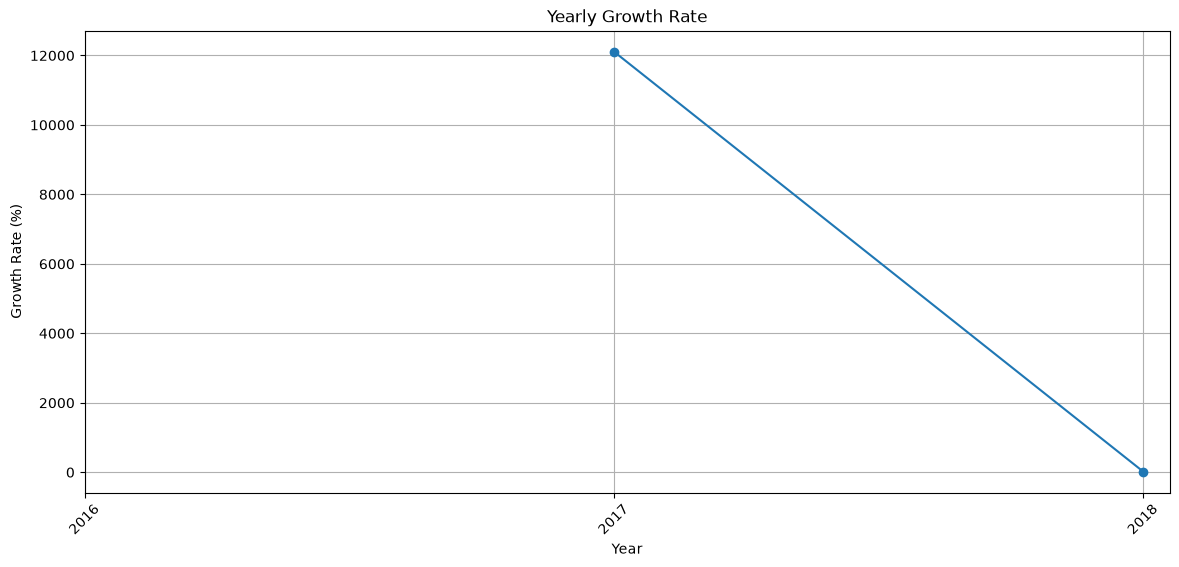

In [25]:
query="""WITH payment_per_order AS (SELECT
    YEAR(order_purchase_timestamp) AS years, ROUND(SUM(payment_value),2) AS payment
FROM
    payments
        JOIN
    orders ON payments.order_id=orders.order_id
GROUP BY years
ORDER BY years)

SELECT years AS Year, payment AS Payment, LAG(payment, 1) OVER (ORDER BY years) AS Previous_Year_Payment, ROUND(((payment - LAG(payment, 1) OVER (ORDER BY years))/LAG(payment, 1) OVER (ORDER BY years))*100,2) AS Growth_Rate
FROM payment_per_order"""

yearly_growth = pd.read_sql(query, mydb)
print(yearly_growth)
plt.figure(figsize=(14, 6))
plt.plot(yearly_growth['Year'], yearly_growth['Growth_Rate'], marker='o', linestyle='-')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.xticks(yearly_growth['Year'], rotation=45)
plt.title('Yearly Growth Rate')
plt.grid()

The `yearly_growth` dataset and the corresponding plot illustrate the annual financial performance by showing total payments and their year-over-year growth rates. The data reveals an initial exceptionally high growth rate from 2016 to 2017, likely due to a low base in 2016. This indicates a strong and consistent expansion phase. This analysis is vital for assessing the business's overall trajectory and informing strategic decisions.

Strategic Business Use Cases and Values:

| Business Use Case                                  | Value                                                                                                        |
| :---------------------------------------- | :----------------------------------------------------------------------------------------------------------- |
| **Performance Evaluation** | Provides a clear quantitative measure of annual business performance, enabling comparison against targets and historical data. |
| **Strategic Direction** | Helps in assessing the effectiveness of past strategies and guiding future business planning and resource allocation. |
| **Investment Decisions** | Crucial for investors and stakeholders to evaluate the company's financial vitality and potential for future returns. |
| **Optimized Capital Allocation** | Guides decisions on where to invest capital for maximum impact, such as expansion, product development, or marketing. |
| **Market Position Analysis** | Indicates how the business is performing relative to the market and competitors in terms of growth. |
| **Competitive Advantage** | Allows for identifying periods of accelerated growth that can be leveraged for sustained market leadership. |
| **Risk Assessment** | Highlights periods of decelerating or negative growth, prompting proactive investigation into potential issues or market shifts. |
| **Proactive Issue Resolution** | Enables early identification of financial challenges, allowing for timely adjustments to mitigate risks and maintain profitability. |

## Top 3 customers who spent the most money in each year

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23104\988242703.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_customers = pd.read_sql(query, mydb)


   Year                       Customer_ID  Total_Spent  Customer_Rank
0  2016  a9dc96b027d1252bbac0a9b72d837fc6      1423.55              1
1  2016  1d34ed25963d5aae4cf3d7f3a4cda173      1400.74              2
2  2016  4a06381959b6670756de02e07b83815f      1227.78              3
3  2017  1617b1357756262bfa56ab541c47bc16     13664.08              1
4  2017  c6e2731c5b391845f6800c97401a43a9      6929.31              2
5  2017  3fd6777bbce08a352fddd04e4a7cc8f6      6726.66              3
6  2018  ec5b2ba62e574342386871631fafd3fc      7274.88              1
7  2018  f48d464a0baaea338cb25f816991ab1f      6922.21              2
8  2018  e0a2412720e9ea4f26c1ac985f6a7358      4809.44              3


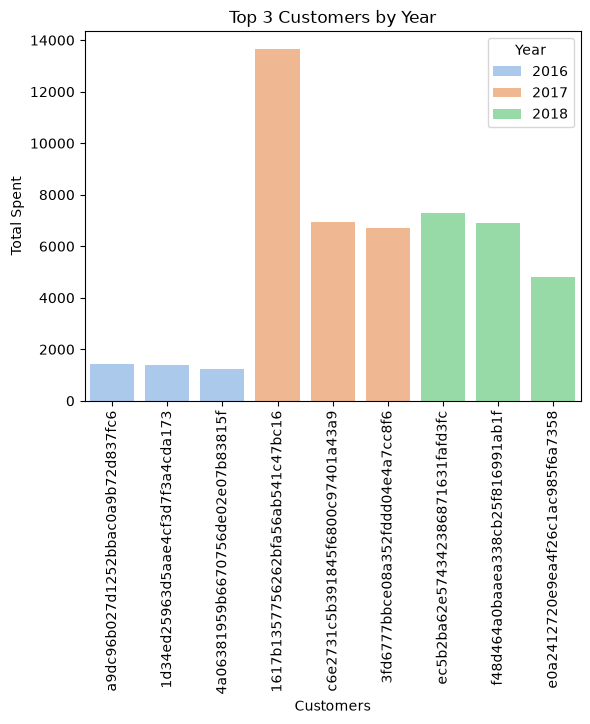

In [29]:
query="""WITH top_spenders AS (SELECT
    YEAR(order_purchase_timestamp) AS years, customer_id, SUM(payment_value) AS payment, DENSE_RANK()
        OVER
    (PARTITION BY YEAR(order_purchase_timestamp) ORDER BY SUM(payment_value) DESC) AS ranks
FROM
    payments
        JOIN
    orders ON payments.order_id=orders.order_id
GROUP BY YEAR(order_purchase_timestamp), customer_id)

SELECT years AS Year, customer_id AS Customer_ID, ROUND(payment,2) AS Total_Spent, ranks AS Customer_Rank FROM top_spenders WHERE ranks<=3"""

top_customers = pd.read_sql(query, mydb)
print(top_customers)
sns.barplot(x='Customer_ID', y='Total_Spent', hue='Year', data=top_customers, palette='pastel')
plt.xlabel('Customers')
plt.ylabel('Total Spent')
plt.xticks(rotation=90)
plt.title('Top 3 Customers by Year')
plt.show()

This analysis identifies the top 3 highest-spending customers for each year by joining order and payment data. The rise of spending from 2016 to 2017 shows the opportunity for inspection of customers behavior, logistics operations, and other factors which caused this to better make expansion and retention strategy, providing insights into customer loyalty and spending patterns over time.

Strategic Business Use Cases & Values:

| **Use Case** | **Business Value** | **Strategic Impact** |
|---|---|---|
| **VIP Customer Program** | Identify top spenders for exclusive benefits and personalized service | Increase customer retention and lifetime value |
| **Account Management Priority** | Allocate premium sales resources to highest-value customers | Maximize ROI on customer relationship investments |
| **Churn Prevention** | Monitor spending patterns of top customers for early warning signs | Protect high-value revenue streams |
| **Cross-sell/Upsell Targeting** | Focus premium product offerings on customers with highest spending capacity | Increase average order value and revenue per customer |
| **Marketing Budget Allocation** | Prioritize marketing spend on proven high-value customer segments | Improve marketing efficiency and campaign ROI |
| **Customer Segmentation** | Create tier-based service levels based on spending history | Optimize service delivery and resource allocation |
| **Revenue Forecasting** | Use top customer trends to predict future revenue patterns | Enhance financial planning and business strategy |

**Key Metric:** Tracks year-over-year performance of top revenue generators, enabling data-driven customer relationship strategies.

## Conclusion

This analysis of e-commerce data reveals significant insights into customer behavior and sales performance. Key findings include a **diverse customer base across 4,119 cities**, **substantial year-over-year order growth from 2016 to 2018** (from 329 to 54,011 orders), and **"BED TABLE BATH" as the top-performing product category**. The data also highlights a **dominant preference for installment payments (49.4% of orders)**.

These insights are crucial for optimizing marketing strategies, streamlining operations, refining product portfolios, and enhancing financial forecasting, ultimately driving sustained profitability and market expansion.